In [1]:
!pwd
!ls -lh

/mnt/workspace
总计 328K
-rw-r--r-- 1 root root 323K  5月 14 18:10 cow.obj
-rw-r--r-- 1 root root  332  5月 14 18:11 work6_differentiable_rendering.ipynb


In [2]:
# 1. 升级包管理工具
!pip install --upgrade pip

# 2. 安装前置依赖项与加速器（ninja 用于多核加速编译）
!pip install fvcore iopath matplotlib ninja

# 3. 使用 Gitee 链接直接源码编译安装
# ⚠️ 注意：加入 --no-build-isolation 可以防止某些云平台的严格沙箱隔离导致的编译报错
# 整个过程大约需要 5-10 分钟，请耐心等待！
!pip install "git+https://gitee.com/hongwenzhang/pytorch3d.git" --no-build-isolation

Looking in indexes: https://mirrors.cloud.aliyuncs.com/pypi/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 27.5 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: pip
    Found existing installation: pip 23.3.2
    Uninstalling pip-23.3.2:
      Successfully uninstalled pip-23.3.2
Looking in indexes: https://mirrors.cloud.aliyuncs.com/pypi/simple
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for fvcore: filename=fvcore-0.1.5.post20221221-py3-none-any.whl size=61443 sha256=8ebb0bea48a2230b4c30e1580e097aa2cf7a0e72f23e6aef0edc6af6caf9a658
  Stored in directory: /root/.cache/pip/wheels/f6/44/9b/cd6191e137e248451f5d90caffab706f75e3b4b5bde8b9c403
  Created wheel for iopath: filename=iopath-0.1.10-py3-none-any.whl size=31596 sha256=f12c1c538

In [3]:
import os
import torch
import pytorch3d

print("当前目录:", os.getcwd())
print("当前目录文件:", os.listdir("."))

print("PyTorch 版本:", torch.__version__)
print("CUDA 是否可用:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU 名称:", torch.cuda.get_device_name(0))
    print("CUDA 版本:", torch.version.cuda)

print("PyTorch3D 版本:", pytorch3d.__version__)

当前目录: /mnt/workspace
当前目录文件: ['.configs', 'cow.obj', 'work6_differentiable_rendering.ipynb']
PyTorch 版本: 2.9.1+cu128
CUDA 是否可用: True
GPU 名称: NVIDIA A10
CUDA 版本: 12.8
PyTorch3D 版本: 0.7.9


In [4]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

from pytorch3d.io import load_obj, save_obj
from pytorch3d.structures import Meshes

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

obj_path = "cow.obj"

if not os.path.exists(obj_path):
    raise FileNotFoundError("没有找到 cow.obj，请确认 cow.obj 和 notebook 在同一个目录下。")

verts, faces, _ = load_obj(obj_path)

faces_idx = faces.verts_idx.to(device)
verts = verts.to(device)

# 模型归一化：平移到中心，并缩放到统一大小
verts = verts - verts.mean(dim=0)
verts = verts / verts.abs().max()

cow_mesh = Meshes(
    verts=[verts],
    faces=[faces_idx]
)

print("cow.obj 读取成功！")
print("顶点数量:", verts.shape)
print("面片数量:", faces_idx.shape)
print("运行设备:", device)

/usr/local/lib/python3.11/site-packages/pytorch3d/io/obj_io.py:551: UserWarning: Mtl file does not exist: cow.mtl
  warnings.warn(f"Mtl file does not exist: {f}")


cow.obj 读取成功！
顶点数量: torch.Size([2930, 3])
面片数量: torch.Size([5856, 3])
运行设备: cuda:0


In [5]:
assets_dir = "work6_assets"
mesh_dir = "work6_output_meshes"

os.makedirs(assets_dir, exist_ok=True)
os.makedirs(mesh_dir, exist_ok=True)

print("图片输出目录:", assets_dir)
print("模型输出目录:", mesh_dir)

图片输出目录: work6_assets
模型输出目录: work6_output_meshes


In [6]:
from pytorch3d.renderer import (
    look_at_view_transform,
    FoVPerspectiveCameras,
    RasterizationSettings,
    MeshRasterizer,
    SoftSilhouetteShader,
    BlendParams,
)

# 多视角数量
num_views = 20
image_size = 256

# 从一圈角度观察奶牛
elev = torch.zeros(num_views, device=device)
azim = torch.linspace(-180, 180, num_views, device=device)

R, T = look_at_view_transform(
    dist=2.7,
    elev=elev,
    azim=azim,
    device=device,
)

cameras = FoVPerspectiveCameras(
    device=device,
    R=R,
    T=T,
)

# Soft Rasterization 参数
sigma = 1e-4

raster_settings = RasterizationSettings(
    image_size=image_size,
    blur_radius=np.log(1.0 / sigma - 1.0) * sigma,
    faces_per_pixel=50,
)

rasterizer = MeshRasterizer(
    cameras=cameras,
    raster_settings=raster_settings,
)

shader = SoftSilhouetteShader(
    blend_params=BlendParams(
        sigma=sigma,
        gamma=sigma,
    )
)

print("软剪影渲染器创建完成。")

软剪影渲染器创建完成。


目标剪影 shape: torch.Size([20, 256, 256])


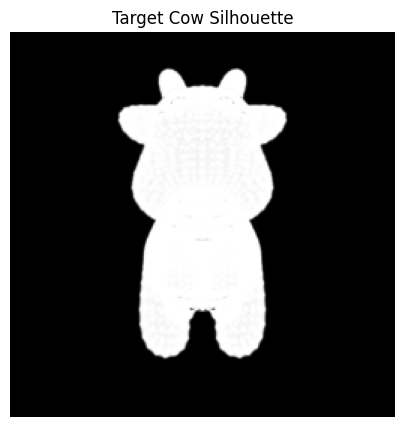

已保存: work6_assets/target_silhouette_view0.png


In [7]:
with torch.no_grad():
    target_silhouette = shader(
        rasterizer(cow_mesh.extend(num_views)),
        cow_mesh.extend(num_views),
    )[..., 3]

print("目标剪影 shape:", target_silhouette.shape)

plt.figure(figsize=(5, 5))
plt.imshow(target_silhouette[0].detach().cpu().numpy(), cmap="gray")
plt.title("Target Cow Silhouette")
plt.axis("off")

target_path = os.path.join(assets_dir, "target_silhouette_view0.png")
plt.savefig(target_path, dpi=160, bbox_inches="tight")
plt.show()

print("已保存:", target_path)

Epoch 299/300 | Total Loss: 0.014604 | Silhouette Loss: 0.009451 | Laplacian: 0.004531 | Edge: 0.004149 | Normal: 0.020740


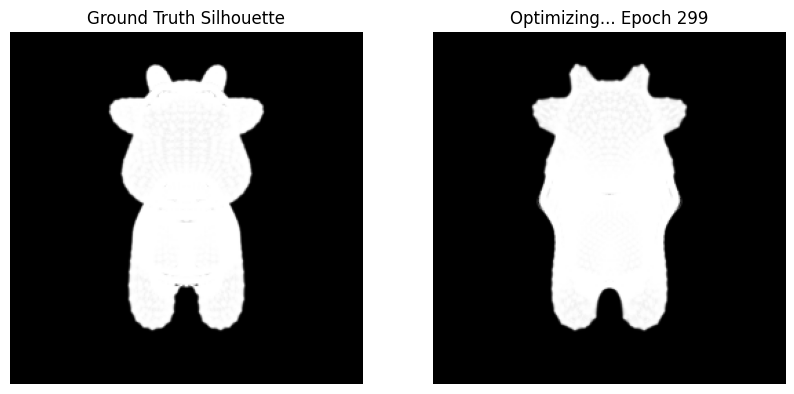

最终低难度模型已保存: work6_output_meshes/final_low_silhouette_mesh.obj
优化过程 GIF 已保存: work6_assets/low_silhouette_optimization.gif


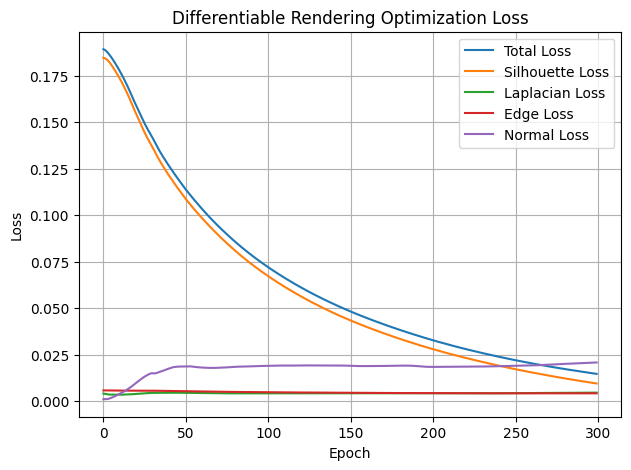

Loss 曲线已保存: work6_assets/low_loss_curve.png


In [8]:
import os
import torch
import matplotlib.pyplot as plt
import imageio.v2 as imageio

from IPython.display import clear_output
from pytorch3d.utils import ico_sphere
from pytorch3d.loss import (
    mesh_edge_loss,
    mesh_laplacian_smoothing,
    mesh_normal_consistency,
)
from pytorch3d.io import save_obj

# =========================
# 1. 初始化源模型：球体
# =========================

src_mesh = ico_sphere(4, device=device)

# deform_verts 是真正参与梯度下降的可微变量
deform_verts = torch.zeros_like(
    src_mesh.verts_packed(),
    device=device,
    requires_grad=True,
)

optimizer = torch.optim.SGD(
    [deform_verts],
    lr=1.0,
    momentum=0.9,
)

# =========================
# 2. 损失权重设置
# =========================

epochs = 300

w_lap = 1.0
w_edge = 0.1
w_normal = 0.01

loss_history = []
silhouette_history = []
lap_history = []
edge_history = []
normal_history = []

frame_paths = []
display_interval = 20

print("开始低难度剪影优化：sphere -> cow silhouette")

# =========================
# 3. 优化循环
# =========================

for i in range(epochs):
    optimizer.zero_grad()

    # 当前形变后的球体网格
    new_src_mesh = src_mesh.offset_verts(deform_verts)

    # 渲染当前网格的多视角剪影
    pred_silhouette = shader(
        rasterizer(new_src_mesh.extend(num_views)),
        new_src_mesh.extend(num_views),
    )[..., 3]

    # 剪影损失：让当前投影轮廓接近 cow.obj 的目标剪影
    loss_silhouette = ((pred_silhouette - target_silhouette) ** 2).mean()

    # 网格正则化：防止模型变成刺猬、尖刺、破碎网格
    loss_lap = mesh_laplacian_smoothing(new_src_mesh)
    loss_edge = mesh_edge_loss(new_src_mesh)
    loss_normal = mesh_normal_consistency(new_src_mesh)

    # 总损失
    loss = (
        loss_silhouette
        + w_lap * loss_lap
        + w_edge * loss_edge
        + w_normal * loss_normal
    )

    loss.backward()
    optimizer.step()

    # 记录 loss，后面用于画曲线
    loss_history.append(loss.item())
    silhouette_history.append(loss_silhouette.item())
    lap_history.append(loss_lap.item())
    edge_history.append(loss_edge.item())
    normal_history.append(loss_normal.item())

    # 定期保存图片和模型
    if i % display_interval == 0 or i == epochs - 1:
        clear_output(wait=True)

        print(
            f"Epoch {i:03d}/{epochs} | "
            f"Total Loss: {loss.item():.6f} | "
            f"Silhouette Loss: {loss_silhouette.item():.6f} | "
            f"Laplacian: {loss_lap.item():.6f} | "
            f"Edge: {loss_edge.item():.6f} | "
            f"Normal: {loss_normal.item():.6f}"
        )

        # 保存当前 OBJ
        current_verts = new_src_mesh.verts_list()[0]
        current_faces = new_src_mesh.faces_list()[0]

        obj_save_path = os.path.join(mesh_dir, f"mesh_epoch_{i:03d}.obj")
        save_obj(obj_save_path, current_verts, current_faces)

        # 保存对比图
        fig, ax = plt.subplots(1, 2, figsize=(10, 5))

        ax[0].imshow(target_silhouette[0].detach().cpu().numpy(), cmap="gray")
        ax[0].set_title("Ground Truth Silhouette")
        ax[0].axis("off")

        ax[1].imshow(pred_silhouette[0].detach().cpu().numpy(), cmap="gray")
        ax[1].set_title(f"Optimizing... Epoch {i}")
        ax[1].axis("off")

        frame_path = os.path.join(assets_dir, f"low_compare_epoch_{i:03d}.png")
        plt.savefig(frame_path, dpi=160, bbox_inches="tight")
        plt.show()

        frame_paths.append(frame_path)

# =========================
# 4. 保存最终模型
# =========================

final_mesh = src_mesh.offset_verts(deform_verts)
final_verts = final_mesh.verts_list()[0]
final_faces = final_mesh.faces_list()[0]

final_obj_path = os.path.join(mesh_dir, "final_low_silhouette_mesh.obj")
save_obj(final_obj_path, final_verts, final_faces)

print("最终低难度模型已保存:", final_obj_path)

# =========================
# 5. 生成优化过程 GIF
# =========================

frames = [imageio.imread(path) for path in frame_paths]
gif_path = os.path.join(assets_dir, "low_silhouette_optimization.gif")
imageio.mimsave(gif_path, frames, fps=4)

print("优化过程 GIF 已保存:", gif_path)

# =========================
# 6. 保存 Loss 曲线
# =========================

plt.figure(figsize=(7, 5))
plt.plot(loss_history, label="Total Loss")
plt.plot(silhouette_history, label="Silhouette Loss")
plt.plot(lap_history, label="Laplacian Loss")
plt.plot(edge_history, label="Edge Loss")
plt.plot(normal_history, label="Normal Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Differentiable Rendering Optimization Loss")
plt.legend()
plt.grid(True)

loss_curve_path = os.path.join(assets_dir, "low_loss_curve.png")
plt.savefig(loss_curve_path, dpi=160, bbox_inches="tight")
plt.show()

print("Loss 曲线已保存:", loss_curve_path)

In [9]:
# =========================
# 0. 备份低难度版本
# =========================

!cp work6_differentiable_rendering.ipynb work6_low_silhouette.ipynb
!mkdir -p work6_high_assets
!mkdir -p work6_high_output_meshes

print("低难度 Notebook 已备份为: work6_low_silhouette.ipynb")
print("高难度图片目录: work6_high_assets")
print("高难度模型目录: work6_high_output_meshes")

低难度 Notebook 已备份为: work6_low_silhouette.ipynb
高难度图片目录: work6_high_assets
高难度模型目录: work6_high_output_meshes


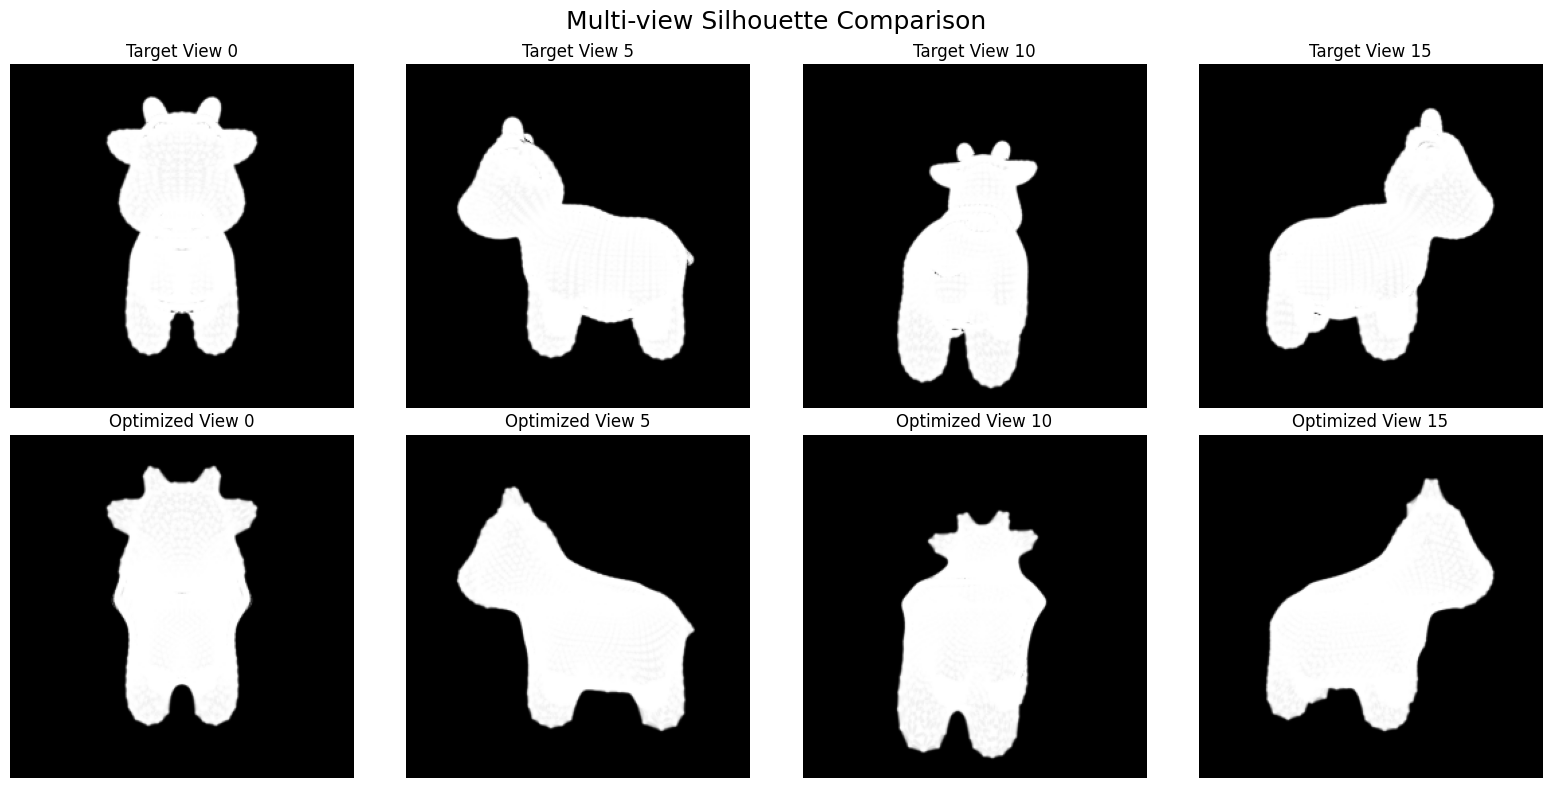

多视角剪影对比图已保存: work6_high_assets/high_multiview_silhouette_compare.png


In [10]:
# =========================
# 高难度 A：多视角剪影对比图
# =========================

import os
import torch
import matplotlib.pyplot as plt

# 使用低难度最终优化出的 final_mesh
# 如果你的 kernel 没重启，final_mesh 应该还在内存里
if "final_mesh" not in globals():
    raise RuntimeError("没有找到 final_mesh。请确认低难度优化 Cell 已经运行完成，或者不要重启 kernel。")

with torch.no_grad():
    final_pred_silhouette = shader(
        rasterizer(final_mesh.extend(num_views)),
        final_mesh.extend(num_views),
    )[..., 3]

selected_views = [0, 5, 10, 15]

fig, axes = plt.subplots(2, len(selected_views), figsize=(4 * len(selected_views), 8))

for col, view_id in enumerate(selected_views):
    axes[0, col].imshow(target_silhouette[view_id].detach().cpu().numpy(), cmap="gray")
    axes[0, col].set_title(f"Target View {view_id}")
    axes[0, col].axis("off")

    axes[1, col].imshow(final_pred_silhouette[view_id].detach().cpu().numpy(), cmap="gray")
    axes[1, col].set_title(f"Optimized View {view_id}")
    axes[1, col].axis("off")

plt.suptitle("Multi-view Silhouette Comparison", fontsize=18)
plt.tight_layout()

multiview_path = os.path.join("work6_high_assets", "high_multiview_silhouette_compare.png")
plt.savefig(multiview_path, dpi=180, bbox_inches="tight")
plt.show()

print("多视角剪影对比图已保存:", multiview_path)

In [11]:
# =========================
# 高难度 B-1：建立 RGB 渲染器
# =========================

import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio

from IPython.display import clear_output

from pytorch3d.structures import Meshes
from pytorch3d.renderer import (
    TexturesVertex,
    MeshRenderer,
    MeshRasterizer,
    SoftPhongShader,
    PointLights,
    FoVPerspectiveCameras,
    RasterizationSettings,
    BlendParams,
    look_at_view_transform,
    SoftSilhouetteShader,
)
from pytorch3d.loss import (
    mesh_edge_loss,
    mesh_laplacian_smoothing,
    mesh_normal_consistency,
)

high_assets_dir = "work6_high_assets"
high_mesh_dir = "work6_high_output_meshes"

os.makedirs(high_assets_dir, exist_ok=True)
os.makedirs(high_mesh_dir, exist_ok=True)

# 高难度版用稍小一点的分辨率，避免 RGB 优化太慢
high_num_views = 12
high_image_size = 192

high_elev = torch.zeros(high_num_views, device=device)
high_azim = torch.linspace(-180, 180, high_num_views, device=device)

R_high, T_high = look_at_view_transform(
    dist=2.7,
    elev=high_elev,
    azim=high_azim,
    device=device,
)

high_cameras = FoVPerspectiveCameras(
    device=device,
    R=R_high,
    T=T_high,
)

# RGB 渲染器：SoftPhongShader
rgb_raster_settings = RasterizationSettings(
    image_size=high_image_size,
    blur_radius=0.0,
    faces_per_pixel=1,
)

lights = PointLights(
    device=device,
    location=[[0.0, 0.0, -3.0]],
)

rgb_renderer = MeshRenderer(
    rasterizer=MeshRasterizer(
        cameras=high_cameras,
        raster_settings=rgb_raster_settings,
    ),
    shader=SoftPhongShader(
        device=device,
        cameras=high_cameras,
        lights=lights,
    ),
)

# 仍然保留软剪影渲染器，用于联合监督形状外轮廓
high_sigma = 1e-4

high_sil_rasterizer = MeshRasterizer(
    cameras=high_cameras,
    raster_settings=RasterizationSettings(
        image_size=high_image_size,
        blur_radius=np.log(1.0 / high_sigma - 1.0) * high_sigma,
        faces_per_pixel=50,
    ),
)

high_sil_shader = SoftSilhouetteShader(
    blend_params=BlendParams(
        sigma=high_sigma,
        gamma=high_sigma,
    )
)

print("高难度 RGB 渲染器与软剪影渲染器创建完成。")

高难度 RGB 渲染器与软剪影渲染器创建完成。


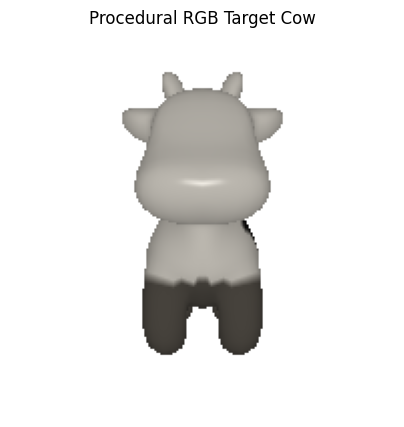

高难度目标 RGB 图已保存: work6_high_assets/high_target_rgb_view0.png
target_rgb shape: torch.Size([12, 192, 192, 3])
target_high_silhouette shape: torch.Size([12, 192, 192])


In [12]:
# =========================
# 高难度 B-2：构造目标牛的程序化顶点颜色
# =========================

def make_procedural_cow_colors(verts_tensor):
    """
    为没有材质文件的 cow.obj 构造一组程序化顶点颜色。
    输出范围为 [0, 1]。
    """
    x = verts_tensor[:, 0]
    y = verts_tensor[:, 1]
    z = verts_tensor[:, 2]

    # 基础颜色：偏白的牛身体
    colors = torch.ones_like(verts_tensor)
    colors[:, 0] = 0.92
    colors[:, 1] = 0.90
    colors[:, 2] = 0.86

    # 程序化深色斑块：用若干个高斯区域模拟花纹
    spot1 = torch.exp(-((x - 0.28) ** 2 + (y - 0.05) ** 2 + (z - 0.10) ** 2) / 0.045)
    spot2 = torch.exp(-((x + 0.25) ** 2 + (y + 0.10) ** 2 + (z + 0.05) ** 2) / 0.055)
    spot3 = torch.exp(-((x - 0.05) ** 2 + (y - 0.28) ** 2 + (z - 0.12) ** 2) / 0.035)
    spot4 = torch.exp(-((x + 0.10) ** 2 + (y + 0.30) ** 2 + (z + 0.15) ** 2) / 0.050)

    spot_mask = (spot1 > 0.45) | (spot2 > 0.45) | (spot3 > 0.45) | (spot4 > 0.45)

    dark_color = torch.tensor([0.06, 0.055, 0.05], device=verts_tensor.device)
    colors[spot_mask] = dark_color

    # 稍微给下方区域加深，模拟腿部阴影
    leg_mask = y < torch.quantile(y, 0.28)
    colors[leg_mask] = torch.minimum(
        colors[leg_mask],
        torch.tensor([0.35, 0.33, 0.30], device=verts_tensor.device),
    )

    return colors.clamp(0.0, 1.0)


target_cow_colors = make_procedural_cow_colors(verts.detach())

target_textured_cow_mesh = Meshes(
    verts=[verts.detach()],
    faces=[faces_idx.detach()],
    textures=TexturesVertex(verts_features=[target_cow_colors]),
)

with torch.no_grad():
    target_rgb_rgba = rgb_renderer(target_textured_cow_mesh.extend(high_num_views))
    target_rgb = target_rgb_rgba[..., :3]

    target_high_silhouette = high_sil_shader(
        high_sil_rasterizer(target_textured_cow_mesh.extend(high_num_views)),
        target_textured_cow_mesh.extend(high_num_views),
    )[..., 3]

plt.figure(figsize=(5, 5))
plt.imshow(target_rgb[0].detach().cpu().clamp(0, 1).numpy())
plt.title("Procedural RGB Target Cow")
plt.axis("off")

target_rgb_path = os.path.join(high_assets_dir, "high_target_rgb_view0.png")
plt.savefig(target_rgb_path, dpi=180, bbox_inches="tight")
plt.show()

print("高难度目标 RGB 图已保存:", target_rgb_path)
print("target_rgb shape:", target_rgb.shape)
print("target_high_silhouette shape:", target_high_silhouette.shape)

High Epoch 179/180 | Total: 0.008324 | Sil: 0.000375 | RGB: 0.003649 | Reg: 0.003176


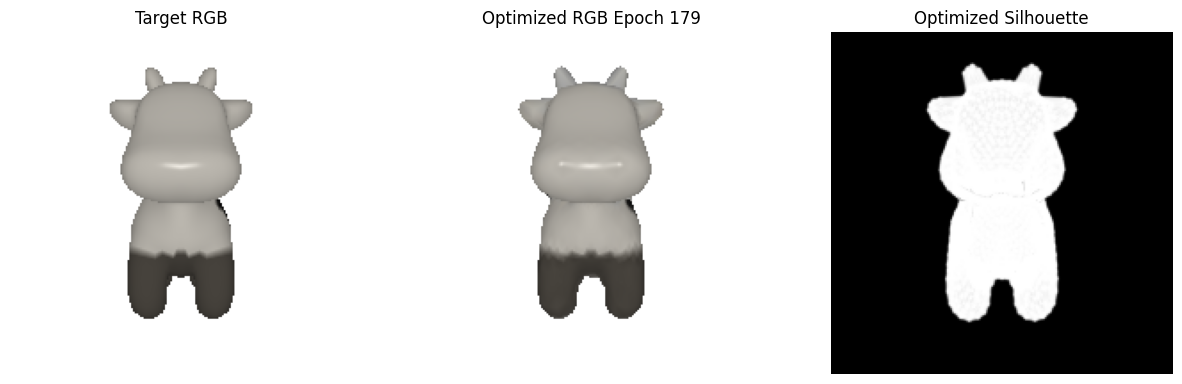

高难度联合优化完成。


In [13]:
# =========================
# 高难度 B-3：RGB + 顶点颜色联合优化
# =========================

if "final_mesh" not in globals():
    raise RuntimeError("没有找到 final_mesh。请先完成低难度优化，或不要重启 kernel。")

# 以低难度最终网格作为高难度初始几何
base_verts_high = final_mesh.verts_list()[0].detach()
base_faces_high = final_mesh.faces_list()[0].detach()

# 几何偏移量：继续优化顶点坐标
high_deform_verts = torch.zeros_like(
    base_verts_high,
    device=device,
    requires_grad=True,
)

# 顶点颜色 logits：通过 sigmoid 映射到 [0, 1]
init_color = torch.full_like(base_verts_high, 0.75, device=device)
high_color_logits = torch.logit(init_color.clamp(1e-4, 1.0 - 1e-4)).detach()
high_color_logits.requires_grad_(True)

# 用于颜色平滑的边集合
base_temp_mesh = Meshes(verts=[base_verts_high], faces=[base_faces_high])
base_edges = base_temp_mesh.edges_packed().detach()

optimizer_high = torch.optim.Adam(
    [
        {"params": [high_deform_verts], "lr": 0.015},
        {"params": [high_color_logits], "lr": 0.080},
    ]
)

high_epochs = 180
high_display_interval = 15

high_total_history = []
high_sil_history = []
high_rgb_history = []
high_reg_history = []

high_frame_paths = []

# 损失权重
lambda_sil = 4.0
lambda_rgb = 1.0
lambda_lap = 0.25
lambda_edge = 0.05
lambda_normal = 0.005
lambda_color = 0.03
lambda_deform = 0.02

print("开始高难度联合优化：silhouette + RGB + vertex colors")

for i in range(high_epochs):
    optimizer_high.zero_grad()

    current_verts_high = base_verts_high + high_deform_verts
    current_colors_high = torch.sigmoid(high_color_logits)

    current_high_mesh = Meshes(
        verts=[current_verts_high],
        faces=[base_faces_high],
        textures=TexturesVertex(verts_features=[current_colors_high]),
    )

    # RGB 渲染
    pred_rgb_rgba = rgb_renderer(current_high_mesh.extend(high_num_views))
    pred_rgb = pred_rgb_rgba[..., :3]

    # 软剪影渲染
    pred_high_silhouette = high_sil_shader(
        high_sil_rasterizer(current_high_mesh.extend(high_num_views)),
        current_high_mesh.extend(high_num_views),
    )[..., 3]

    # RGB loss：只在目标前景区域重点比较，避免黑色背景主导 loss
    foreground_mask = (target_high_silhouette > 0.35).float().unsqueeze(-1)
    loss_rgb = ((pred_rgb - target_rgb) ** 2 * foreground_mask).sum() / (
        foreground_mask.sum() * 3.0 + 1e-6
    )

    # 剪影 loss：保持整体外轮廓
    loss_sil = ((pred_high_silhouette - target_high_silhouette) ** 2).mean()

    # 几何正则
    loss_lap = mesh_laplacian_smoothing(current_high_mesh)
    loss_edge = mesh_edge_loss(current_high_mesh)
    loss_normal = mesh_normal_consistency(current_high_mesh)

    # 颜色平滑：避免顶点颜色噪声过强
    edge_color_diff = current_colors_high[base_edges[:, 0]] - current_colors_high[base_edges[:, 1]]
    loss_color_smooth = (edge_color_diff ** 2).mean()

    # 控制高难度阶段不要把低难度几何完全拉坏
    loss_deform = (high_deform_verts ** 2).mean()

    loss_reg = (
        lambda_lap * loss_lap
        + lambda_edge * loss_edge
        + lambda_normal * loss_normal
        + lambda_color * loss_color_smooth
        + lambda_deform * loss_deform
    )

    loss_high = (
        lambda_sil * loss_sil
        + lambda_rgb * loss_rgb
        + loss_reg
    )

    loss_high.backward()
    optimizer_high.step()

    high_total_history.append(loss_high.item())
    high_sil_history.append(loss_sil.item())
    high_rgb_history.append(loss_rgb.item())
    high_reg_history.append(loss_reg.item())

    if i % high_display_interval == 0 or i == high_epochs - 1:
        clear_output(wait=True)

        print(
            f"High Epoch {i:03d}/{high_epochs} | "
            f"Total: {loss_high.item():.6f} | "
            f"Sil: {loss_sil.item():.6f} | "
            f"RGB: {loss_rgb.item():.6f} | "
            f"Reg: {loss_reg.item():.6f}"
        )

        fig, ax = plt.subplots(1, 3, figsize=(15, 5))

        ax[0].imshow(target_rgb[0].detach().cpu().clamp(0, 1).numpy())
        ax[0].set_title("Target RGB")
        ax[0].axis("off")

        ax[1].imshow(pred_rgb[0].detach().cpu().clamp(0, 1).numpy())
        ax[1].set_title(f"Optimized RGB Epoch {i}")
        ax[1].axis("off")

        ax[2].imshow(pred_high_silhouette[0].detach().cpu().numpy(), cmap="gray")
        ax[2].set_title("Optimized Silhouette")
        ax[2].axis("off")

        frame_path = os.path.join(high_assets_dir, f"high_rgb_epoch_{i:03d}.png")
        plt.savefig(frame_path, dpi=180, bbox_inches="tight")
        plt.show()

        high_frame_paths.append(frame_path)

print("高难度联合优化完成。")

高难度 RGB 优化 GIF 已保存: work6_high_assets/high_rgb_texture_optimization.gif


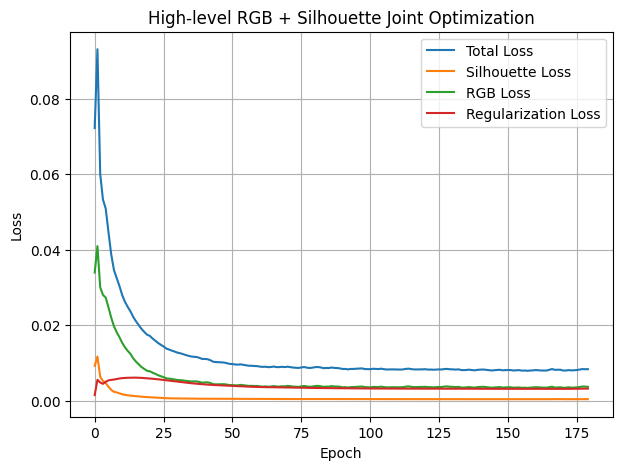

高难度 Loss 曲线已保存: work6_high_assets/high_rgb_loss_curve.png


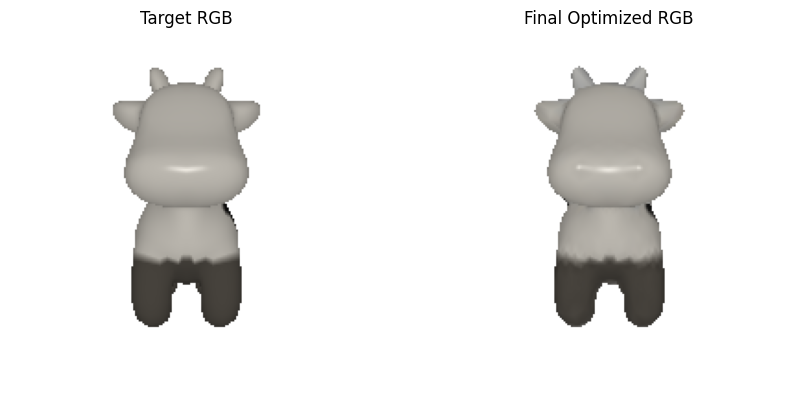

高难度最终 RGB 对比图已保存: work6_high_assets/high_final_rgb_compare.png
高难度彩色 OBJ 已保存: work6_high_output_meshes/final_high_rgb_colored_mesh.obj


In [14]:
# =========================
# 高难度 B-4：保存最终结果
# =========================

import os
import imageio.v2 as imageio
import matplotlib.pyplot as plt

# 最终高难度 mesh
final_high_verts = (base_verts_high + high_deform_verts).detach()
final_high_faces = base_faces_high.detach()
final_high_colors = torch.sigmoid(high_color_logits).detach()

final_high_mesh = Meshes(
    verts=[final_high_verts],
    faces=[final_high_faces],
    textures=TexturesVertex(verts_features=[final_high_colors]),
)

# 生成高难度 GIF
high_gif_path = os.path.join(high_assets_dir, "high_rgb_texture_optimization.gif")
high_frames = [imageio.imread(path) for path in high_frame_paths]
imageio.mimsave(high_gif_path, high_frames, fps=4)

print("高难度 RGB 优化 GIF 已保存:", high_gif_path)

# 保存高难度 loss 曲线
plt.figure(figsize=(7, 5))
plt.plot(high_total_history, label="Total Loss")
plt.plot(high_sil_history, label="Silhouette Loss")
plt.plot(high_rgb_history, label="RGB Loss")
plt.plot(high_reg_history, label="Regularization Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("High-level RGB + Silhouette Joint Optimization")
plt.legend()
plt.grid(True)

high_loss_curve_path = os.path.join(high_assets_dir, "high_rgb_loss_curve.png")
plt.savefig(high_loss_curve_path, dpi=180, bbox_inches="tight")
plt.show()

print("高难度 Loss 曲线已保存:", high_loss_curve_path)

# 保存最终 RGB 对比图
with torch.no_grad():
    final_high_rgba = rgb_renderer(final_high_mesh.extend(high_num_views))
    final_high_rgb = final_high_rgba[..., :3]

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(target_rgb[0].detach().cpu().clamp(0, 1).numpy())
ax[0].set_title("Target RGB")
ax[0].axis("off")

ax[1].imshow(final_high_rgb[0].detach().cpu().clamp(0, 1).numpy())
ax[1].set_title("Final Optimized RGB")
ax[1].axis("off")

high_final_compare_path = os.path.join(high_assets_dir, "high_final_rgb_compare.png")
plt.savefig(high_final_compare_path, dpi=180, bbox_inches="tight")
plt.show()

print("高难度最终 RGB 对比图已保存:", high_final_compare_path)


# 保存带顶点颜色的 OBJ
# 标准 OBJ 不强制支持 vertex color，但很多查看器、MeshLab 可以识别 v x y z r g b 格式
def save_colored_obj(path, verts_tensor, faces_tensor, colors_tensor):
    verts_np = verts_tensor.detach().cpu().numpy()
    faces_np = faces_tensor.detach().cpu().numpy()
    colors_np = colors_tensor.detach().cpu().clamp(0, 1).numpy()

    with open(path, "w") as f:
        f.write("# Colored OBJ generated by Work6 differentiable rendering\n")
        f.write("# Format: v x y z r g b\n")

        for v, c in zip(verts_np, colors_np):
            f.write(
                f"v {v[0]:.6f} {v[1]:.6f} {v[2]:.6f} "
                f"{c[0]:.6f} {c[1]:.6f} {c[2]:.6f}\n"
            )

        for face in faces_np:
            # OBJ face index starts from 1
            f.write(f"f {face[0] + 1} {face[1] + 1} {face[2] + 1}\n")


colored_obj_path = os.path.join(high_mesh_dir, "final_high_rgb_colored_mesh.obj")
save_colored_obj(
    colored_obj_path,
    final_high_verts,
    final_high_faces,
    final_high_colors,
)

print("高难度彩色 OBJ 已保存:", colored_obj_path)

In [15]:
!find work6_high_assets -maxdepth 1 -type f | sort
!find work6_high_output_meshes -maxdepth 1 -type f | sort

work6_high_assets/high_final_rgb_compare.png
work6_high_assets/high_multiview_silhouette_compare.png
work6_high_assets/high_rgb_epoch_000.png
work6_high_assets/high_rgb_epoch_015.png
work6_high_assets/high_rgb_epoch_030.png
work6_high_assets/high_rgb_epoch_045.png
work6_high_assets/high_rgb_epoch_060.png
work6_high_assets/high_rgb_epoch_075.png
work6_high_assets/high_rgb_epoch_090.png
work6_high_assets/high_rgb_epoch_105.png
work6_high_assets/high_rgb_epoch_120.png
work6_high_assets/high_rgb_epoch_135.png
work6_high_assets/high_rgb_epoch_150.png
work6_high_assets/high_rgb_epoch_165.png
work6_high_assets/high_rgb_epoch_179.png
work6_high_assets/high_rgb_loss_curve.png
work6_high_assets/high_rgb_texture_optimization.gif
work6_high_assets/high_target_rgb_view0.png
work6_high_output_meshes/final_high_rgb_colored_mesh.obj


In [17]:
# =========================
# 高难度 C-1：正则化消融实验目录
# =========================

ablation_assets_dir = "work6_ablation_assets"
ablation_mesh_dir = "work6_ablation_output_meshes"

os.makedirs(ablation_assets_dir, exist_ok=True)
os.makedirs(ablation_mesh_dir, exist_ok=True)

print("消融实验图片目录:", ablation_assets_dir)
print("消融实验模型目录:", ablation_mesh_dir)

消融实验图片目录: work6_ablation_assets
消融实验模型目录: work6_ablation_output_meshes


Ablation Epoch 219/220 | Silhouette-only Loss: 0.023288


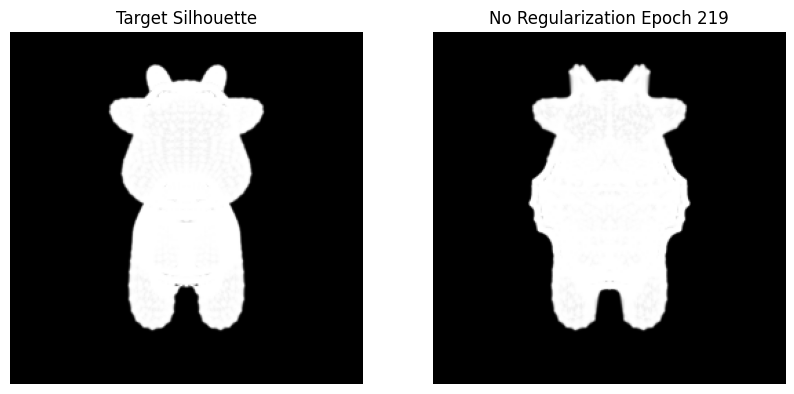

无正则化最终模型已保存: work6_ablation_output_meshes/final_ablation_no_regularization.obj


In [18]:
# =========================
# 高难度 C-2：无正则化消融实验
# =========================

import os
import torch
import matplotlib.pyplot as plt
import imageio.v2 as imageio

from IPython.display import clear_output
from pytorch3d.utils import ico_sphere
from pytorch3d.io import save_obj

# 单独初始化，不复用低难度 deform_verts，避免破坏已有成果
ablation_src_mesh = ico_sphere(4, device=device)

ablation_deform_verts = torch.zeros_like(
    ablation_src_mesh.verts_packed(),
    device=device,
    requires_grad=True,
)

ablation_optimizer = torch.optim.SGD(
    [ablation_deform_verts],
    lr=1.0,
    momentum=0.9,
)

ablation_epochs = 220
ablation_display_interval = 20

ablation_loss_history = []
ablation_frame_paths = []

print("开始消融实验：只使用 silhouette loss，不加入 mesh regularization")

for i in range(ablation_epochs):
    ablation_optimizer.zero_grad()

    ablation_mesh = ablation_src_mesh.offset_verts(ablation_deform_verts)

    ablation_pred_silhouette = shader(
        rasterizer(ablation_mesh.extend(num_views)),
        ablation_mesh.extend(num_views),
    )[..., 3]

    # 只使用剪影损失
    ablation_loss = ((ablation_pred_silhouette - target_silhouette) ** 2).mean()

    ablation_loss.backward()
    ablation_optimizer.step()

    ablation_loss_history.append(ablation_loss.item())

    if i % ablation_display_interval == 0 or i == ablation_epochs - 1:
        clear_output(wait=True)

        print(
            f"Ablation Epoch {i:03d}/{ablation_epochs} | "
            f"Silhouette-only Loss: {ablation_loss.item():.6f}"
        )

        current_verts = ablation_mesh.verts_list()[0]
        current_faces = ablation_mesh.faces_list()[0]

        obj_path = os.path.join(ablation_mesh_dir, f"ablation_no_reg_epoch_{i:03d}.obj")
        save_obj(obj_path, current_verts, current_faces)

        fig, ax = plt.subplots(1, 2, figsize=(10, 5))

        ax[0].imshow(target_silhouette[0].detach().cpu().numpy(), cmap="gray")
        ax[0].set_title("Target Silhouette")
        ax[0].axis("off")

        ax[1].imshow(ablation_pred_silhouette[0].detach().cpu().numpy(), cmap="gray")
        ax[1].set_title(f"No Regularization Epoch {i}")
        ax[1].axis("off")

        frame_path = os.path.join(
            ablation_assets_dir,
            f"ablation_no_reg_epoch_{i:03d}.png"
        )
        plt.savefig(frame_path, dpi=180, bbox_inches="tight")
        plt.show()

        ablation_frame_paths.append(frame_path)

# 保存最终无正则化模型
final_ablation_mesh = ablation_src_mesh.offset_verts(ablation_deform_verts)
final_ablation_verts = final_ablation_mesh.verts_list()[0]
final_ablation_faces = final_ablation_mesh.faces_list()[0]

final_ablation_obj_path = os.path.join(
    ablation_mesh_dir,
    "final_ablation_no_regularization.obj"
)
save_obj(final_ablation_obj_path, final_ablation_verts, final_ablation_faces)

print("无正则化最终模型已保存:", final_ablation_obj_path)

无正则化消融 GIF 已保存: work6_ablation_assets/ablation_no_regularization.gif


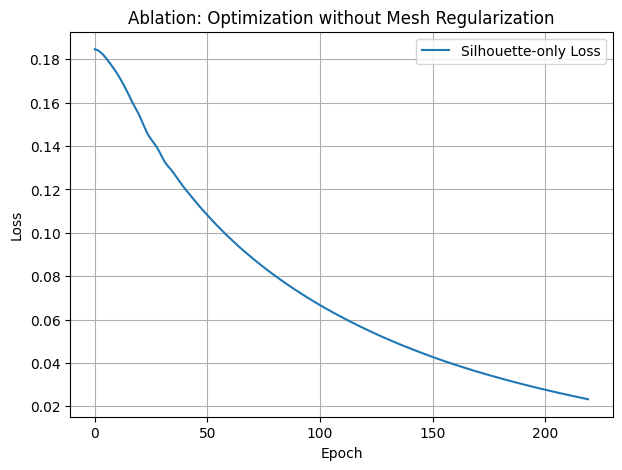

无正则化 Loss 曲线已保存: work6_ablation_assets/ablation_no_regularization_loss_curve.png


In [19]:
# =========================
# 高难度 C-3：保存消融 GIF 与 Loss 曲线
# =========================

# GIF
ablation_gif_path = os.path.join(
    ablation_assets_dir,
    "ablation_no_regularization.gif"
)

ablation_frames = [imageio.imread(path) for path in ablation_frame_paths]
imageio.mimsave(ablation_gif_path, ablation_frames, fps=4)

print("无正则化消融 GIF 已保存:", ablation_gif_path)

# Loss 曲线
plt.figure(figsize=(7, 5))
plt.plot(ablation_loss_history, label="Silhouette-only Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Ablation: Optimization without Mesh Regularization")
plt.legend()
plt.grid(True)

ablation_loss_curve_path = os.path.join(
    ablation_assets_dir,
    "ablation_no_regularization_loss_curve.png"
)

plt.savefig(ablation_loss_curve_path, dpi=180, bbox_inches="tight")
plt.show()

print("无正则化 Loss 曲线已保存:", ablation_loss_curve_path)

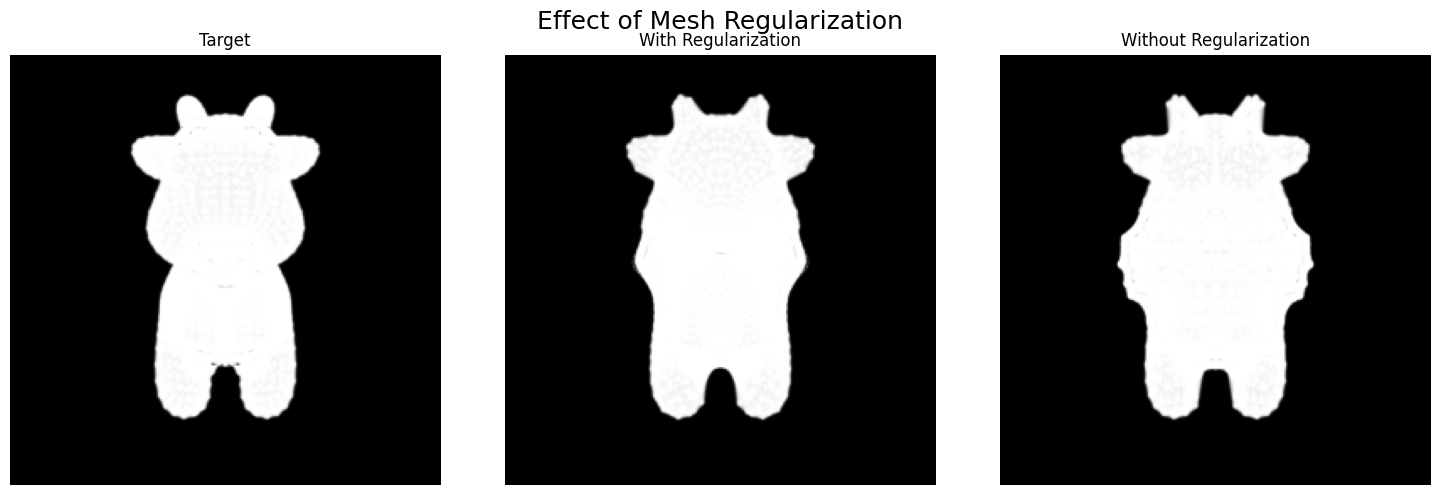

正则化消融对比图已保存: work6_ablation_assets/regularization_ablation_compare.png


In [20]:
# =========================
# 高难度 C-4：正则化效果最终对比图
# =========================

with torch.no_grad():
    # 有正则化结果：使用低难度 final_mesh
    regularized_silhouette = shader(
        rasterizer(final_mesh.extend(num_views)),
        final_mesh.extend(num_views),
    )[..., 3]

    # 无正则化结果
    no_reg_silhouette = shader(
        rasterizer(final_ablation_mesh.extend(num_views)),
        final_ablation_mesh.extend(num_views),
    )[..., 3]

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(target_silhouette[0].detach().cpu().numpy(), cmap="gray")
ax[0].set_title("Target")
ax[0].axis("off")

ax[1].imshow(regularized_silhouette[0].detach().cpu().numpy(), cmap="gray")
ax[1].set_title("With Regularization")
ax[1].axis("off")

ax[2].imshow(no_reg_silhouette[0].detach().cpu().numpy(), cmap="gray")
ax[2].set_title("Without Regularization")
ax[2].axis("off")

plt.suptitle("Effect of Mesh Regularization", fontsize=18)
plt.tight_layout()

ablation_compare_path = os.path.join(
    ablation_assets_dir,
    "regularization_ablation_compare.png"
)

plt.savefig(ablation_compare_path, dpi=180, bbox_inches="tight")
plt.show()

print("正则化消融对比图已保存:", ablation_compare_path)

In [21]:
!find work6_ablation_assets -maxdepth 1 -type f | sort
!find work6_ablation_output_meshes -maxdepth 1 -type f | sort | tail -10

work6_ablation_assets/ablation_no_reg_epoch_000.png
work6_ablation_assets/ablation_no_reg_epoch_020.png
work6_ablation_assets/ablation_no_reg_epoch_040.png
work6_ablation_assets/ablation_no_reg_epoch_060.png
work6_ablation_assets/ablation_no_reg_epoch_080.png
work6_ablation_assets/ablation_no_reg_epoch_100.png
work6_ablation_assets/ablation_no_reg_epoch_120.png
work6_ablation_assets/ablation_no_reg_epoch_140.png
work6_ablation_assets/ablation_no_reg_epoch_160.png
work6_ablation_assets/ablation_no_reg_epoch_180.png
work6_ablation_assets/ablation_no_reg_epoch_200.png
work6_ablation_assets/ablation_no_reg_epoch_219.png
work6_ablation_assets/ablation_no_regularization.gif
work6_ablation_assets/ablation_no_regularization_loss_curve.png
work6_ablation_assets/regularization_ablation_compare.png
work6_ablation_output_meshes/ablation_no_reg_epoch_060.obj
work6_ablation_output_meshes/ablation_no_reg_epoch_080.obj
work6_ablation_output_meshes/ablation_no_reg_epoch_100.obj
work6_ablation_output_me

,Metric,With Regularization,Without Regularization
0,Laplacian Smoothing,0.004540,0.020015
1,Edge Length Loss,0.004150,0.005936
2,Normal Consistency,0.020780,0.146628
3,Edge Length Std,0.022362,0.037163


正则化消融指标表已保存: work6_ablation_assets/regularization_ablation_metrics.csv


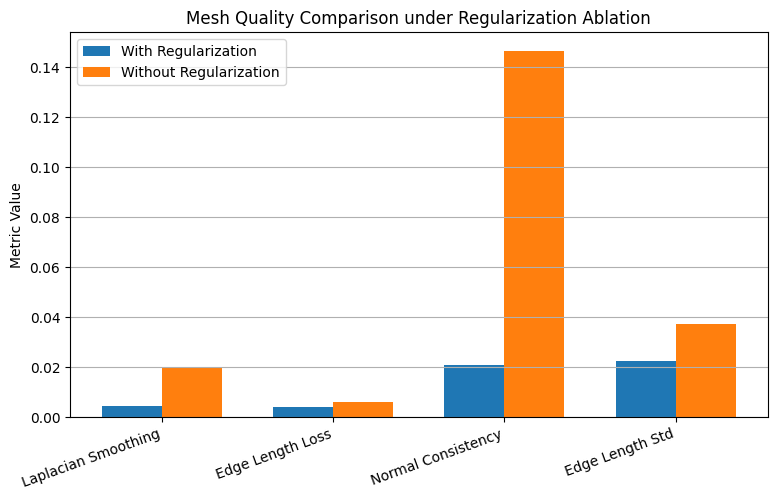

正则化消融指标图已保存: work6_ablation_assets/regularization_ablation_metrics.png


In [22]:
# =========================
# 高难度 C-5：几何质量量化对比
# =========================

import os
import torch
import pandas as pd
import matplotlib.pyplot as plt

from pytorch3d.loss import (
    mesh_laplacian_smoothing,
    mesh_edge_loss,
    mesh_normal_consistency,
)

def compute_edge_length_std(mesh):
    verts_packed = mesh.verts_packed()
    edges_packed = mesh.edges_packed()
    edge_vec = verts_packed[edges_packed[:, 0]] - verts_packed[edges_packed[:, 1]]
    edge_len = torch.norm(edge_vec, dim=1)
    return edge_len.std().item()

# 有正则化版本：低难度最终模型
regularized_mesh = final_mesh

# 无正则化版本：消融最终模型
no_regularization_mesh = final_ablation_mesh

metrics = {
    "Metric": [
        "Laplacian Smoothing",
        "Edge Length Loss",
        "Normal Consistency",
        "Edge Length Std",
    ],
    "With Regularization": [
        mesh_laplacian_smoothing(regularized_mesh).item(),
        mesh_edge_loss(regularized_mesh).item(),
        mesh_normal_consistency(regularized_mesh).item(),
        compute_edge_length_std(regularized_mesh),
    ],
    "Without Regularization": [
        mesh_laplacian_smoothing(no_regularization_mesh).item(),
        mesh_edge_loss(no_regularization_mesh).item(),
        mesh_normal_consistency(no_regularization_mesh).item(),
        compute_edge_length_std(no_regularization_mesh),
    ],
}

df_metrics = pd.DataFrame(metrics)
display(df_metrics)

metric_csv_path = os.path.join(
    ablation_assets_dir,
    "regularization_ablation_metrics.csv"
)
df_metrics.to_csv(metric_csv_path, index=False)

print("正则化消融指标表已保存:", metric_csv_path)

# 画柱状图
plt.figure(figsize=(9, 5))

x = range(len(df_metrics))
bar_width = 0.35

plt.bar(
    [i - bar_width / 2 for i in x],
    df_metrics["With Regularization"],
    width=bar_width,
    label="With Regularization",
)

plt.bar(
    [i + bar_width / 2 for i in x],
    df_metrics["Without Regularization"],
    width=bar_width,
    label="Without Regularization",
)

plt.xticks(x, df_metrics["Metric"], rotation=20, ha="right")
plt.ylabel("Metric Value")
plt.title("Mesh Quality Comparison under Regularization Ablation")
plt.legend()
plt.grid(axis="y")

metric_fig_path = os.path.join(
    ablation_assets_dir,
    "regularization_ablation_metrics.png"
)

plt.savefig(metric_fig_path, dpi=180, bbox_inches="tight")
plt.show()

print("正则化消融指标图已保存:", metric_fig_path)